In [1]:
import sys
sys.path.append("..")
from src.utils import *
from src.features import *
from src.environment import *
from src.potential_outcomes import *
from src.policy import *
from src.outcomes import *
from src.policy_runner import *
from src.outcome_runner import *
from src.generate_doc import *
from src.evaluation import *
from src.plotting import *

In [2]:
generate_doc()

API.md  last updated at 2026-03-26_12-35-15 .


In [3]:
# clear previous results

path = '../results/'
clear_directory('../results/')

# Problem Statement
---

In many ML systems targeting decisions are made using predictions of user outcomes. However, the optimal targeting policy depends on treatment effects rather than predicted outcomes. Prediction models do not estimate treatment effects. This notebook demonstrates this distinction using a simulated environment.


I will compare Prediction targeting vs tteatment effect targeting vs Random targeting.



Let $\mathcal{ I} = \{1,2, \dots , I\}$ be the set of users. We will index them by $i$. Let $X_i = (x_{i1}, x_{i2}, \dots, x_{iM}) \in\mathcal{R}^M $ be the features associated with user $i$.



We are interested in the outcome of these users. Let $Y_i \in \{0,1\}$ be the outcome for users $i$, where $Y_i = 1$  means user $i$ is retained.

 
 The firm has an option to send a targeted discount to each of its users. Let  $D_i \in \{0,1\}$ represent the treatment status of user $i$, where $D_i = 1$  means user $i$ is treated (given discount).



# Optimization Problem
---

The firm wants to maximise retention . Firm has

1. Objective: maximize retention $Y = \sum Y_i$
2. Choice Variable: by choosing a vector  $ D \in \{0,1\}^I$ 
3. Constraints: subject to budget constraints $\sum D_i \leq K \leq I$   






For ease of exposition we are assuming that each coupon costs the same. So budget constraint is how many coupons we can give. We will vary $K$ and see how things change. 

Later  on we will take different objective functions and derive resulst for them. For different objective functions and their derivation see Appendix A1.

# Potential Outcomes
---

Note: if you are new to potential outcomes notation of causal inference you can look at Appendix A1.

 Note that a user will either get a coupon or not get a coupon. So there are two **potential outcomes** for each user. 

 Let's rewrite  outcomes of users to incorporate treatment.

let $Y_i(D_i)$ represent user $i$'s potential outcomes. So $Y_i( 1)$ is the outcome when $i$ receives coupon and $Y_i(0)$ is the outcome when $i$ does not receive a coupon.  If user $i$ is assigned to treatment we will observe $Y_i(1)$, else we will observe $Y_i(0)$.  So out of two potential outcomes we will only get to observe one. The observed outcome is called **realised outcome** $Y_i$.  So one potential outcome is observed and the other will be **counterfactual**.




We can express the realised outcome in terms of potential outcomes as follows:


  $\boxed{Y_i = D_i \times Y_i(1) + [1 - D_i] \times Y_i(0)}     \hspace{2cm}       $       

  This is the **switching equation** which allows us to connect realised outcomes and potential outcomes.


**Individual Treatment Effect**

(Causal)  impact of treatment is the difference between potential outcomes. So for user $i$, impact of discount $\tau_i$ is the difference in outcomes when user is given a treatment and outcome that would have happened had this user not been given the treatmen.

so $\tau_i = Y_i(1) - Y_i(0).$ 



We can express the observed outcome in terms of treatment effect as follows:


$\boxed{Y_i = D_i \times \tau_i + Y_i(0)}$

# Optimal Policy Derivation
---

Back to the firm's optimisation problem:


- Choice Variable: choose a vector  $ D \in \{0,1\}^I$ 
- Subject to budget constraints: $\sum D_i \leq K$   
- maximize: $Y = \sum Y_i$

Steps:

1. Rewrite realised outcomes in terms of treatment effects: 

    $\sum Y_i = \sum  [ D_i \times \tau_i + Y_i(0) ] \implies \sum D_i \times \tau_i + \sum Y_i(0)$

2.  Note that $Y_i( 0)$ is independant of $D$ (see remark below).

3. therefore maximizing $Y_i$ is equivalent to maximising $\tau_i \times D_i$
4. maximizing $Y$ is equivalent to maximising each of the $Y_i's$ in isolation (see remark below). 
5. And so the problem becomes:

    $ \text{ maximize }_{D \in \{0,1\}^I}  \sum D_i \times \tau_i   \text{ such that } \sum D_i \leq K$


It is straightforward to verify that the solution of this problem (in step 5) is to choose the top $K$ users according to their treatment effects $\tau$


--- 

Assumptions:

A note on step 2 and 4 above. 

For step (2) to be valid, the potential outcome of a user must not depend on the treatment assignments of other users.



This assumption is called Stable Unit Treatment Value Assumption (SUTVA). It consists of two components:

(i) no interference between units and

(ii) consistency (a unique version of each treatment level).

  SUTVA:     $Y_i(D_1, D_2, \cdots, D_I) = Y_i(D_i) $    

These assumptions can fail in multiple settings. 

1. Failure of no interference assumption in marketplaces: Failure of the no-interference assumption in marketplaces.
Consider a ride-sharing platform where riders are randomized into treatment and control groups. Suppose riders in the treatment group receive a discount. This increases ride demand among treated users. Since driver supply is fixed in the short run, more drivers become occupied serving treated riders. As a result, control-group riders face longer wait times. Increased wait times reduce their probability of booking a ride. Thus the outcome of a control user depends on the treatment assignment of other users, violating the no-interference assumption.

    rider discount → more demand  from TG → fewer drivers available for CG → longer wait times 

2. Failure of consistency: Suppose users in the treatment group are assigned a ₹100 discount. If some users receive the discount as cashback, others as an upfront fare reduction, and others as a post-ride coupon, then these correspond to different treatment versions. Even though the monetary value is identical, user behavior may differ across delivery modes, violating the consistency component of SUTVA.




In this notebook we assume SUTVA holds so that each user’s potential outcomes depend only on their own treatment status. This assumption rules out equilibrium effects across users. In many marketplaces, however, treatment applied to one side of the platform can change outcomes for others through supply–demand interactions.


**An Additional Assumption**

To make our lives easier I will assume **Full Compliance**, that is, there is 100% conversion from platform giving coupon --> user availing coupon. Cases of non-compliance where targeted users self select into accepting discount will be handled later ( it will use additional causal machinery: instrumental variables).

**Recap**


If goal is to maximise retention under budget constrain $K$ then the optimal policy is to treat the $K$ users with the largest treatment effects.



You can toy with other objective functions and derive optimal targeting rules (**policy**) following the steps above (be explicit if you need to make more assumptions). We have a list of interesting objective functions with derivation of optimal policy. In all the cases optimal policy is to target based on some function of treatment effects. 



# Structural Model
---

We assume that user retention decisions follow a latent utility model where utility of staying for user $i$ is given by:

 $U_i(x_i, D_i) = f(x_i) + D_i \times g(x_i) + \epsilon_i  $   where $f(x_i)$ is the baseline index,  $g(x_i)$ is the treatment index and  $ \theta_i = f(x_i) + D_i \times g(x_i)$ is the systematic part of utility.
 
 Users remain active if the utility of staying exceeds an outside option. We normalise the utility of outside option to 0. So user $i$ stays if $U_i(x_i, D_i) > 0.$

 So $P[Y_i = 1] = P[U_i(x_i, D_i) > 0] =  P[\theta_i + \epsilon_i > 0] =  P[\epsilon_i > - \theta_i ] = 1 - P[\epsilon_i \leq - \theta_i ] $ 

Let $F$ be the cumulative distribution function (CDF) of $\epsilon_i$. Then  $P[\epsilon_i \leq - \theta_i ] = F(-\theta_i)$ and therefore probability of retention

$\boxed{P(Y_i = 1) = 1 -  F(-\theta_i)}$

One way to understand this equation is as follows: suppose for some user their systematic portion of utility ($\theta$) is very high, then in order for them to churn their idiosyncratic shock $\epsilon$ will have to be negative extreme. And so higher the $\theta$ lower the $\epsilon$ will have to be in order for the user to churn. Since lower $\epsilon$ has lower probability of happening, higher $\theta$ user has higher probability of being retained.

 This is what is captured in the boxed equation above: $\theta \uparrow \implies   -\theta \downarrow \implies F(-\theta)  \downarrow \implies P(Y_i = 1) \uparrow .$
 


Note that 
1. these targeted coupons can have negative utility too (no restriction on $g$ to be non-negative). Think of a situation where you are sending a notification to users that they have a discount. Depending on user context at that time these notifications can lead to churn. 
2. We are not worried too much about *utility being negative*. We are interested in making comparisons here instead of computing welfare and so I have not worried too much about keeping utility non-negative and ensuring law of diminishing marginal utility property holds.



Let's focus on two central objects, probability of retention with and without discounts:


1. Probability of retention without discount, $P(Y_i = 1 | D_i= 0)$, denoted in short by $p_0(x_i) $:
   
    after plugging $D_i = 0$ we get

     $p_0(x_i) = 1 - F(-f(x_i)) $.

2. Probability of retention with discount, $P(Y_i = 1 | D_i= 1)$, denoted in short by $ p_1(x_i) $:  
   
   after plugging $D_i = 1$ we get
   
    $p_1(x_i) = 1 -  F(-f(x_i) - g(x_i)) $, 




So potential outcomes of users  follow bernoulli distributions:

$Y(0) \sim Bernoulli(p_0(x))$

$Y(1) \sim Bernoulli(p_1(x))$

and therefore  $E[Y(0)] = p_0(x)$ and $E[Y(1)] = p_1(x)$.




Recall that $\tau_i = Y_i(1) - Y_i(0)$ and so

 $E[\tau_i] = E[Y_i(1)] - E[Y_i(0)] = p_1(x_i) - p_0(x_i)$
 
 $ = (1 - F[-f(x_i) - g(x_i)]) - (1 -  F[-f(x_i])) = F(-f(x_i)) - F(-f(x_i) - g(x_i)) $ 

$\boxed{E[\tau_i] = F(-f(x_i)) - F(-f(x_i) - g(x_i))}$ 


Note that treatment index $g$ determines how treatment varies across users.

# Simulation Environment
---


1. Only two features: for ease of visualisation
2. Logistic Error: for ease of computation
3. functional forms of f and g



## Configuration

The entire analysis is reproducible from a single call: `main(config_name)`.
All simulation inputs are defined in a `config_name.json` file in configs folder  and loaded at runtime. 
The config is the single source of truth for the analysis and will be  updates it as and  when new dimensions are needed.


| Key | Description |
|---|---|
| `I` | Number of users in the simulation |
| `seed` | Random seed for reproducibility |
| `features` | Feature definitions : name, distribution, and parameters. |
| `outcome_model.baseline_coeff` | Coefficients for $f(x_i)$  |
| `outcome_model.treatment_coeff` | Coefficients for $g(x_i)$  |
| `objective` | Targeting objective(s) to evaluate.  |
| `profit_coeff` | LTV weights per feature : used for profit objective |
| `cost_coeff` | Treatment cost weights : used for profit objective  |
| `policies` | List of policies to simulate and compare. Each policy has a `name` and optional parameters (`K` = budget, `score_col` = scoring column) |

Current policies: `treat_none`, `random`, `score` (targets on $p_0$), `causal` (targets on treatment effects).

 

In [4]:
config = load_config('notebook_1', verbose = True)

Config loaded:
{
  "I": 100000,
  "seed": 16,
  "features": {
    "engagement_score": {
      "dist": "normal",
      "mean": 0,
      "std": 1
    },
    "price_sensitivity": {
      "dist": "normal",
      "mean": 0,
      "std": 1
    }
  },
  "outcome_model": {
    "baseline_coeff": [
      -0.2,
      0.8,
      0.3
    ],
    "treatment_coeff": [
      0.4,
      -0.7,
      0.3
    ]
  },
  "objective": [
    "retention"
  ],
  "profit_coeff": [],
  "cost_coeff": [],
  "policies": [
    {
      "name": "treat_none"
    },
    {
      "name": "treat_all"
    },
    {
      "name": "random",
      "K": 10000
    },
    {
      "name": "score",
      "score_col": "score",
      "K": 10000
    },
    {
      "name": "causal",
      "K": 10000
    }
  ]
}


In [5]:
validate_config(config)

'config is valid'


There are I = 100000 users. For each user we observe two features: 

- $x_1$ (engagement_score) : captures users recent activity
- $x_2$ (price_sensitivity) : a proxy for price sensitivity

Choice of keeping only two features is driven purely by pedagogical purpose (visualisations will be clean). The derivation extends to any number of features.



In [6]:
config.keys()

dict_keys(['I', 'seed', 'features', 'outcome_model', 'objective', 'profit_coeff', 'cost_coeff', 'policies'])

In [7]:
features =  config.get('features')
features

{'engagement_score': {'dist': 'normal', 'mean': 0, 'std': 1},
 'price_sensitivity': {'dist': 'normal', 'mean': 0, 'std': 1}}

In [8]:
generate_features(config)

{'engagement_score': array([ 1.18815483, -0.54209719, -0.03823887, ...,  1.13014915,
        -0.36059857, -0.62281678]),
 'price_sensitivity': array([-0.89654979, -0.31898255,  0.19762154, ..., -0.67063334,
         0.23919196, -0.02000322])}




For simplicity let 

$f(x_i) = -0.2 + 0.8 \text{ engagement score}_i + 0.3 \text{ price sensitivity}_i $  (baseline index)

and

$g(x_i) =  0.4 - 0.7 \text{ engagement score}_i + 0.9 \text{ price sensitivity}_i $  (treatment index)

In [9]:
outcome_model = config.get('outcome_model')
outcome_model

{'baseline_coeff': [-0.2, 0.8, 0.3], 'treatment_coeff': [0.4, -0.7, 0.3]}

assuming logistic error in the random utility model $F$ will take a logistic form and so
 
$p_0(x_i) = \frac{1}{1 + e^-f(x_i)}$

$p_1(x_i) = \frac{1}{1 + e^-[f(x_i) + g(x_i)]}$

and treatment effect $E[\tau_i] = p_1(x_i) - p_0(x_i)$.

In [10]:
df_base = generate_environment(config)
df_base

,user_id,engagement_score,price_sensitivity,baseline_index,treatment_index,p0,p1,tau
0,1,0.127949,0.642684,0.095164,0.503241,0.523773,0.645291,0.121518
1,2,-1.528473,-0.747270,-1.646960,1.245750,0.161520,0.401022,0.239502
2,3,-0.594468,0.341854,-0.573018,0.918684,0.360541,0.585566,0.225025
3,4,0.066330,0.741166,0.075414,0.575919,0.518845,0.657311,0.138466
4,5,-1.235495,1.453657,-0.752299,1.700944,0.320321,0.720843,0.400522
...,...,...,...,...,...,...,...,...
99995,99996,0.850844,-0.017020,0.475570,-0.200697,0.616701,0.568289,-0.048412
99996,99997,-0.120787,-1.530235,-0.755700,0.025480,0.319581,0.325146,0.005566
99997,99998,0.243382,0.362487,0.103452,0.338379,0.525840,0.608695,0.082855
99998,99999,-2.176678,-0.987249,-2.237517,1.627500,0.096432,0.352055,0.255624


In [11]:
df_base['score'] = 1 - df_base['p0']     # probbaility of churn

This environment becomes our base df. We can keep it fixed draw  potential outcomes repeatedly to run simulations.

In order to draw potential outcomes we generate a random number, u, from Random Uniform (0,1). Then we put $Y0$ as 0 (1) if probability of retention without discount, $p_0$,is less than (greater) than u. Similary for $Y1$ by comparing $p_1$ with u. Drawing the same error makes sure that our potential outcomes are subject to same underlying shocks which gurantees monotonic outcomse $p_1 \geq p_0 \implies Y1 \geq Y0$.

In [12]:

df_po = draw_potential_outcomes(df_base)
df_po.head()

,user_id,engagement_score,price_sensitivity,baseline_index,treatment_index,p0,p1,tau,score,U,Y0,Y1
0,1,0.127949,0.642684,0.095164,0.503241,0.523773,0.645291,0.121518,0.476227,0.771347,0,0
1,2,-1.528473,-0.747270,-1.646960,1.245750,0.161520,0.401022,0.239502,0.838480,0.084415,1,1
2,3,-0.594468,0.341854,-0.573018,0.918684,0.360541,0.585566,0.225025,0.639459,0.047769,1,1
3,4,0.066330,0.741166,0.075414,0.575919,0.518845,0.657311,0.138466,0.481155,0.834193,0,0
4,5,-1.235495,1.453657,-0.752299,1.700944,0.320321,0.720843,0.400522,0.679679,0.350959,0,1


A policy is a mapping that for each user takes as input their features and outputs treat/not treat.

 Formally policy $\pi$ is :

$\pi: X \to \{0,1\}$

where  $X$ is the feature space (user context) and 0/1 refer to treat/ not treat that user.

Some common policies are:
- treat_all: Treat all the users irrespective of context
- treat_none: Treat none of the users irrespective of context
- treat_random_K: Treat a randomly chosen K users.
- treat_score: Treat users for whom score column is above a certain threshold
- treat_causal: Treat users for whom treatment effect is above a certain threshold (note that in code we can implemenet treat_score via treat_causal too but have kept it separate for now)

In [13]:
assign_policy(df_po, policy='treat_none')


,user_id,engagement_score,price_sensitivity,baseline_index,treatment_index,p0,p1,tau,score,U,Y0,Y1,D_treat_none
0,1,0.127949,0.642684,0.095164,0.503241,0.523773,0.645291,0.121518,0.476227,0.771347,0,0,0
1,2,-1.528473,-0.747270,-1.646960,1.245750,0.161520,0.401022,0.239502,0.838480,0.084415,1,1,0
2,3,-0.594468,0.341854,-0.573018,0.918684,0.360541,0.585566,0.225025,0.639459,0.047769,1,1,0
3,4,0.066330,0.741166,0.075414,0.575919,0.518845,0.657311,0.138466,0.481155,0.834193,0,0,0
4,5,-1.235495,1.453657,-0.752299,1.700944,0.320321,0.720843,0.400522,0.679679,0.350959,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,0.850844,-0.017020,0.475570,-0.200697,0.616701,0.568289,-0.048412,0.383299,0.084386,1,1,0
99996,99997,-0.120787,-1.530235,-0.755700,0.025480,0.319581,0.325146,0.005566,0.680419,0.545192,0,0,0
99997,99998,0.243382,0.362487,0.103452,0.338379,0.525840,0.608695,0.082855,0.474160,0.123425,1,1,0
99998,99999,-2.176678,-0.987249,-2.237517,1.627500,0.096432,0.352055,0.255624,0.903568,0.465386,0,0,0


In [14]:
policies = config.get('policies')
df_policies = apply_policies(df_po, policies)
df_policies.head()

,user_id,engagement_score,price_sensitivity,baseline_index,treatment_index,p0,p1,tau,score,U,Y0,Y1,D_treat_none,D_treat_all,D_random,D_score,D_causal
0,1,0.127949,0.642684,0.095164,0.503241,0.523773,0.645291,0.121518,0.476227,0.771347,0,0,0,1,0,0,0
1,2,-1.528473,-0.747270,-1.646960,1.245750,0.161520,0.401022,0.239502,0.838480,0.084415,1,1,0,1,1,1,0
2,3,-0.594468,0.341854,-0.573018,0.918684,0.360541,0.585566,0.225025,0.639459,0.047769,1,1,0,1,0,0,0
3,4,0.066330,0.741166,0.075414,0.575919,0.518845,0.657311,0.138466,0.481155,0.834193,0,0,0,1,0,0,0
4,5,-1.235495,1.453657,-0.752299,1.700944,0.320321,0.720843,0.400522,0.679679,0.350959,0,1,0,1,0,0,1


In [15]:
policy_cols = [f"D_{p['name']}" for p in policies]

realised_outcomes

Given a policy and potential ouctomes, we generate realised outcome using the switching equation:

$Y_i = D_i \times Y_i(1) + [1 - D_i] \times Y_i(0)$

In [16]:
realised_outcome(df_policies, 'D_treat_none')

,user_id,engagement_score,price_sensitivity,baseline_index,treatment_index,p0,p1,tau,score,U,Y0,Y1,D_treat_none,D_treat_all,D_random,D_score,D_causal,Y_treat_none
0,1,0.127949,0.642684,0.095164,0.503241,0.523773,0.645291,0.121518,0.476227,0.771347,0,0,0,1,0,0,0,0
1,2,-1.528473,-0.747270,-1.646960,1.245750,0.161520,0.401022,0.239502,0.838480,0.084415,1,1,0,1,1,1,0,1
2,3,-0.594468,0.341854,-0.573018,0.918684,0.360541,0.585566,0.225025,0.639459,0.047769,1,1,0,1,0,0,0,1
3,4,0.066330,0.741166,0.075414,0.575919,0.518845,0.657311,0.138466,0.481155,0.834193,0,0,0,1,0,0,0,0
4,5,-1.235495,1.453657,-0.752299,1.700944,0.320321,0.720843,0.400522,0.679679,0.350959,0,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,0.850844,-0.017020,0.475570,-0.200697,0.616701,0.568289,-0.048412,0.383299,0.084386,1,1,0,1,0,0,0,1
99996,99997,-0.120787,-1.530235,-0.755700,0.025480,0.319581,0.325146,0.005566,0.680419,0.545192,0,0,0,1,0,0,0,0
99997,99998,0.243382,0.362487,0.103452,0.338379,0.525840,0.608695,0.082855,0.474160,0.123425,1,1,0,1,0,0,0,1
99998,99999,-2.176678,-0.987249,-2.237517,1.627500,0.096432,0.352055,0.255624,0.903568,0.465386,0,0,0,1,0,1,0,0


In [17]:
df_outcomes = apply_realised_outcomes(df_policies, policy_cols)
df_outcomes.head()

,user_id,engagement_score,price_sensitivity,baseline_index,treatment_index,p0,p1,tau,score,U,...,D_treat_none,D_treat_all,D_random,D_score,D_causal,Y_treat_none,Y_treat_all,Y_random,Y_score,Y_causal
0,1,0.127949,0.642684,0.095164,0.503241,0.523773,0.645291,0.121518,0.476227,0.771347,...,0,1,0,0,0,0,0,0,0,0
1,2,-1.528473,-0.747270,-1.646960,1.245750,0.161520,0.401022,0.239502,0.838480,0.084415,...,0,1,1,1,0,1,1,1,1,1
2,3,-0.594468,0.341854,-0.573018,0.918684,0.360541,0.585566,0.225025,0.639459,0.047769,...,0,1,0,0,0,1,1,1,1,1
3,4,0.066330,0.741166,0.075414,0.575919,0.518845,0.657311,0.138466,0.481155,0.834193,...,0,1,0,0,0,0,0,0,0,0
4,5,-1.235495,1.453657,-0.752299,1.700944,0.320321,0.720843,0.400522,0.679679,0.350959,...,0,1,0,0,1,0,1,0,0,1


In [18]:
df_outcomes[policy_cols].sum()

D_treat_none         0
D_treat_all     100000
D_random         10000
D_score          10000
D_causal         10000
dtype: int64

Evaluating Policies:

Recall that our objective is to find optimal policy for maximising cumulative retention. So to judge policies we can look at how many people are retained under that policy when compared to our baseline of doing nothing (treat_none policy).

In [19]:
outcome_cols = [f"Y_{p['name']}" for p in policies]
outcome_cols

['Y_treat_none', 'Y_treat_all', 'Y_random', 'Y_score', 'Y_causal']

In [20]:
a = df_outcomes[outcome_cols].sum()
# a.to_frame().T

pd.DataFrame(a).T

,Y_treat_none,Y_treat_all,Y_random,Y_score,Y_causal
0,45849,54656,46733,48470,49644


Say it looks like by doing nothing we have a baseline retention of 45.8% and by following these other policies we get 46.7% (from random), 49.6% (from causal), 44.7% (from score). 

- Note that all policies except score do better than baseline for this draw. 
- In particular causal seems to do the best.
- Ignore treat_all since its not yet a fair comparison (it gives 100000 discounts instead of 10000 given by others)


In order to do a meaningful comparison we need to rerun this simulation multiple times and average the results.

# Evaluation

In order to do a meaningful comparison we need to rerun this simulation multiple times and average the results.

For our simulation we will draw a based_df (user_id, features, baseline/treatmemt index, p0, p1, tau) that will be fixed for all iterations. In each iteration we will
1. draw potential ouctomes
2. apply policies (note that since all policies accept random are deterministic) all policy realisations will be same.
   
Finally we will collate and save the dataframe that results from this simulation so our datframe will have each row corresponding to one run_id and contain number of retained users (our metric of interest) for each of our policies.

| run_id | 	treat_none |	treat_all |	random |	score |	causal |
|---|---|---|---|---|---|


In [21]:
df_base.head()

,user_id,engagement_score,price_sensitivity,baseline_index,treatment_index,p0,p1,tau,score
0,1,0.127949,0.642684,0.095164,0.503241,0.523773,0.645291,0.121518,0.476227
1,2,-1.528473,-0.747270,-1.646960,1.245750,0.161520,0.401022,0.239502,0.838480
2,3,-0.594468,0.341854,-0.573018,0.918684,0.360541,0.585566,0.225025,0.639459
3,4,0.066330,0.741166,0.075414,0.575919,0.518845,0.657311,0.138466,0.481155
4,5,-1.235495,1.453657,-0.752299,1.700944,0.320321,0.720843,0.400522,0.679679


In [22]:
result = run_simulations(df = df_base, policies = policies, num_simulations= 1000)

final_result_df = make_result_df(result)

final_result_df

,run_id,treat_none,treat_all,random,score,causal
0,0,45574,54503,46430,48172,49360
1,1,45791,54727,46631,48479,49586
2,2,45726,54661,46680,48365,49433
3,3,45464,54374,46350,48006,49171
4,4,45609,54377,46437,48169,49329
...,...,...,...,...,...,...
995,995,45909,54803,46852,48597,49660
996,996,45891,54801,46848,48585,49640
997,997,45753,54638,46591,48405,49570
998,998,45703,54646,46630,48298,49382


# Results
 We can visualise the results above. We can ask questions like:

 1. In a random run what can we expect the outcome of each policy to be? So expected number of retention with confidence intervals.
 2. Visualise the distribution of these outcomes.
 3. Which policy wins most often?
 4. CDF: Is one policy uniformly better?
   

We can ask these questions wrt any outcome of interest. Below we have answered these for outcome = total_retention, later on we can add other outcomes.






In [23]:
df_long = get_df_long(final_result_df, id_vars = 'run_id', var_name='policy', value_name='outcome' )
get_summary(df_long)


,mean,ci_lower,ci_upper
policy,,,
causal,49441.670,49432.638757,49450.701243
random,46586.992,46577.981104,46596.002896
score,48329.915,48320.738001,48339.091999
treat_all,54600.153,54590.706669,54609.599331
treat_none,45696.681,45687.788648,45705.573352


In [24]:
policy_rank_modal(df_long)

,policy,probability
0,treat_all,1.0


In [25]:
policy_rank_modal(df_long, exclude = ['treat_all'])

,policy,probability
0,causal,1.0


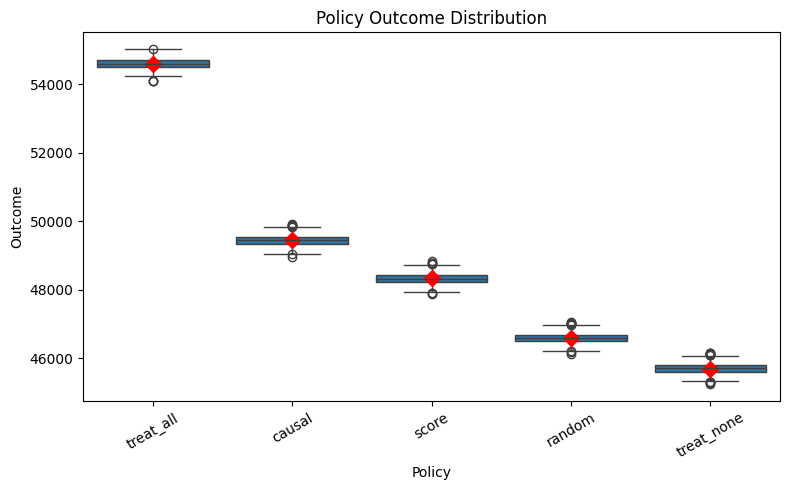

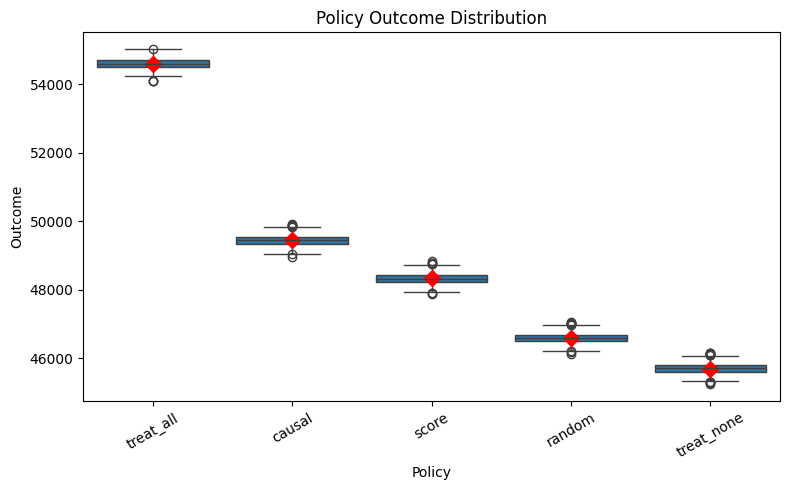

In [26]:
plot_policy_distribution(df_long, metric='outcome', order = None)

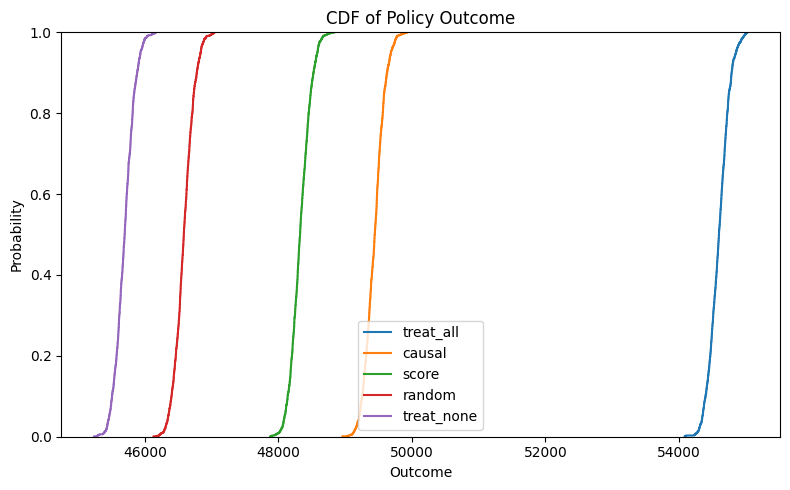

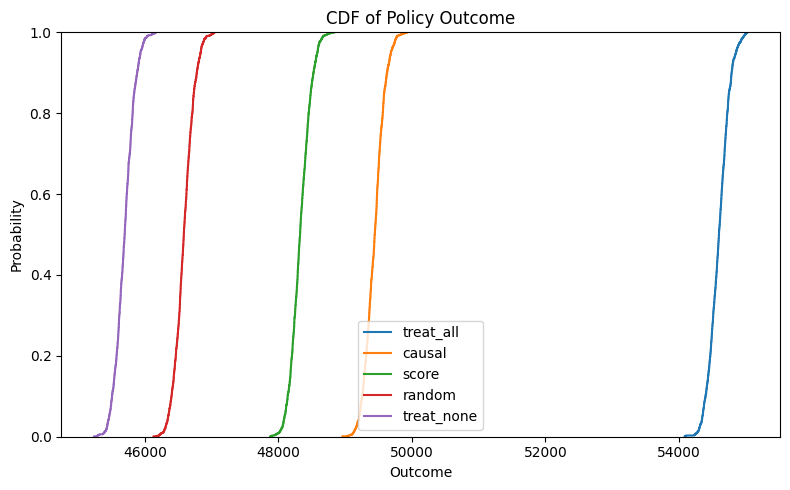

In [27]:
plot_policy_ecdf(df_long, metric='outcome', order = None)

# Conclusion
---

We can see that causal (oracle) does uniformly better than all other policies. This is not surprising since that is what we derived mathematically. One point to note is that ML Oracle performs worst here (even less retention compared to doing nothing). This is an artifact of correlation between p0 and treatment effects.

# One Experiment

We can wrap everything above into one py file. See notebook_1.py in experiments folder.

Upon calling main() we can generate all the artifacts above and save it in '../results/notebook_1_nitesh_{timestamp}' folder.

The artifacts are:
1. arguments: contains config used to run
2. data: 
   - df_base: 
   - final_result_df:
   - df_long:
   - summary_df:
   - df_modal_winner:
   - df_modal_winner_minus_treat_all:
3. figures
   - policy_distribution:
   - policy_ecdf: 

I have kept the names of artifacts used in this notebook and the ones saved in results folder as same for easy comparison. We can tweak names and many other things in experiments.py

This experiments.py structure allows us to iterate faster.


In [28]:
import sys
sys.path.append('..')
import experiments.notebook_1 as nb1

In [30]:
nb1.main('notebook_1', num_simulations= 1000)

Saved DataFrame → ../results/notebook_1_nitesh_2026-03-26_12-36-54/data/df_base.csv
Saved DataFrame → ../results/notebook_1_nitesh_2026-03-26_12-36-54/data/final_result_df.csv
Saved DataFrame → ../results/notebook_1_nitesh_2026-03-26_12-36-54/data/df_long.csv
Saved DataFrame → ../results/notebook_1_nitesh_2026-03-26_12-36-54/data/summary_df.csv
Saved DataFrame → ../results/notebook_1_nitesh_2026-03-26_12-36-54/data/df_modal_winner.csv
Saved DataFrame → ../results/notebook_1_nitesh_2026-03-26_12-36-54/data/df_modal_winner_minus_treat_all.csv
Saved plot → ../results/notebook_1_nitesh_2026-03-26_12-36-54/figures/policy_distribution.jpg
Saved plot → ../results/notebook_1_nitesh_2026-03-26_12-36-54/figures/policy_ecdf.jpg
